# Endangered Globe — Data Pipeline

Produces `animals.geojson`: one or more label Points per threatened species, with label, IUCN category, latest assessment metadata, and Wikipedia popularity. Also writes `animals-spatial.geojson`, a heavier sidecar with the dissolved source geometry for each species.

The notebook starts in **sample mode** by default: it reads taxon IDs from the local IUCN spatial packages, then fetches IUCN Red List API v4 details only for those spatially relevant taxa. Switch to `RUN_MODE = "full_mammals"` for mammals, `RUN_MODE = "full_other"` for reptiles/amphibians/crustaceans, `RUN_MODE = "full_fish"` for sharks/rays/chimaeras and freshwater fish, or `RUN_MODE = "full_birds"` for birds.

**Steps**
1. Query latest global IUCN assessments for selected animal classes
2. Compute label points from IUCN habitat polygons or observation points
3. Wikidata SPARQL → Wikipedia article title
4. Wikimedia Pageviews API → 12-month view count
5. Assemble & export GeoJSON

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install requests pandas tqdm geopandas shapely

import importlib
import os, time, json, subprocess, sys
from pathlib import Path
from datetime import date

import requests
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm
from shapely.geometry import mapping
from shapely.ops import unary_union

import scripts.pipeline_helpers as ph
ph = importlib.reload(ph)
from scripts.pipeline_helpers import *


---
## 0 · Configuration

In [2]:
RUN_MODE = "sample"  # one of "sample", "full_mammals", "full_other", "full_fish", or "full_birds"

IUCN_TOKEN_FILE = Path("data/secrets/iucn_token.txt")
IUCN_TOKEN = os.getenv("IUCN_TOKEN") or read_local_secret(IUCN_TOKEN_FILE)  # Required for both sample and full modes
USER_AGENT = "EndangeredGlobe/1.0 (tdemareuil@gmail.com)"  # Wikimedia requires this

TARGET_CATEGORIES = ["EW", "CR", "EN", "VU", "NT", "CD"]  # CD → displayed as NT
SLEEP_WIKI = 0.15   # seconds between Wikimedia requests
SLEEP_IUCN = 0.5    # IUCN recommends >= 0.5s between calls

OUTPUT_PATH = "animals.geojson"
SPATIAL_OUTPUT_PATH = "animals-spatial.geojson"
SPATIAL_DATA_DIR = "data/shapefiles"
CLEAN_SPATIAL_TARGETS_PATH = "data/processed/iucn_target_taxa.csv"
CLEAN_SPATIAL_OUTPUT_PATH = "data/processed/iucn_spatial_clean.geojson"
CLEAN_SPATIAL_PARENT_TARGETS_PATH = "data/processed/iucn_parent_spatial_fallback_taxa.csv"
CLEAN_SPATIAL_PARENT_OUTPUT_PATH = "data/processed/iucn_parent_spatial_fallback.geojson"
RUN_SPATIAL_CLEANING = True
IUCN_RED_LIST_VERSION = "2025-2"  # Update if your spatial download uses another Red List version
IUCN_RED_LIST_VERSION_YEAR = "2025"
IUCN_DATA_LAST_UPDATED = "10 October 2025"
SPATIAL_DATA_DOWNLOAD_DATE = "14 June 2026"  # Update to the actual IUCN spatial download date
IUCN_DATASET_CITATION = f"IUCN {IUCN_RED_LIST_VERSION_YEAR}. The IUCN Red List of Threatened Species. Version {IUCN_RED_LIST_VERSION}. https://www.iucnredlist.org. Downloaded on {SPATIAL_DATA_DOWNLOAD_DATE}."
SAMPLE_LIMIT = 200
MAX_RANGE_CENTROIDS_PER_SPECIES = 3
RANGE_CLUSTER_BUFFER_KM = 200
SECONDARY_RANGE_CLUSTER_MIN_SHARE = 0.05
USE_IUCN_CACHE = True
GLOBAL_SCOPE_CODE = 1

ph.configure(
    IUCN_TOKEN=IUCN_TOKEN,
    USER_AGENT=USER_AGENT,
    TARGET_CATEGORIES=TARGET_CATEGORIES,
    SLEEP_WIKI=SLEEP_WIKI,
    SLEEP_IUCN=SLEEP_IUCN,
    SPATIAL_DATA_DIR=SPATIAL_DATA_DIR,
    SAMPLE_LIMIT=SAMPLE_LIMIT,
    USE_IUCN_CACHE=USE_IUCN_CACHE,
    GLOBAL_SCOPE_CODE=GLOBAL_SCOPE_CODE,
    IUCN_RED_LIST_VERSION=IUCN_RED_LIST_VERSION,
    IUCN_DATASET_CITATION=IUCN_DATASET_CITATION,
    SPATIAL_DATA_DOWNLOAD_DATE=SPATIAL_DATA_DOWNLOAD_DATE,
    IUCN_DATA_LAST_UPDATED=IUCN_DATA_LAST_UPDATED,
)


---
## 1 · Species list

Default sample path: read mammal taxon IDs from the local mammal spatial package, then fetch a small IUCN detail set so test runs stay quick.

Mammal full path: set `RUN_MODE = "full_mammals"` to process taxa present in the local mammal spatial package.

Other full path: set `RUN_MODE = "full_other"` to process taxa present in the local Reptilia, Amphibia, and selected crustacean spatial packages.

Fish full path: set `RUN_MODE = "full_fish"` to process taxa present in the local freshwater fish and sharks/rays/chimaeras spatial packages, without querying broad marine fish classes.

Subspecies nuance: only shapefile taxa with endangered spatial categories are fetched from the API. If one of those fetched/displayable parent species reports threatened infrarank children that are absent from the shapefiles, those children can be displayed while inheriting the parent species geometry as a lookup source.

Ignored edge case for speed and simplicity: a non-threatened parent species whose missing infrarank child is threatened and absent from the shapefiles. We do not fetch LC/DD/NE parent taxa just to search for this case.


In [3]:
spatial_manifest = selected_spatial_manifest_for_run_mode(RUN_MODE)
df = fetch_iucn_species_from_spatial_manifest(spatial_manifest)
print(f"{RUN_MODE} mode before dedup: {len(df):,} display taxa from IUCN")

df.head()


Spatial-package whitelist for sample: MAMMALS
  MAMMALS: MAMMALS_PART1.shp → 3,098 unique taxon IDs; 942 with displayable spatial category
  MAMMALS: MAMMALS_PART2.shp → 2,838 unique taxon IDs; 822 with displayable spatial category
Spatial category prefilter: 1,764/5,936 taxa kept for IUCN fetch; 4,172 skipped as non-displayable spatial categories; 0 had no spatial category and were kept
Spatial whitelist taxa fetched by API: 200


Fetch IUCN from spatial IDs:   0%|          | 0/200 [00:00<?, ?it/s]

IUCN spatial-package fetch summary
- Spatial seed taxa fetched from API: 200
- Display rows kept: 234 (200 direct shapefile taxa + 34 children using parent geometry)
- Missing-spatial child candidates tested from displayable parents: 50
- Missing-spatial children added with parent geometry: 34
- Parent rows not used for child discovery after API validation: 0
- Self rows skipped by shapefile category prefilter: 0
- Child/self rows skipped after API detail: 16 (missing_child_assessment: 10, detail_category_out_of_scope:NE: 3, detail_category_out_of_scope:DD: 3)
- Duplicate rows ignored: 0
sample mode before dedup: 234 display taxa from IUCN


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,parent_taxonid,child_infrarank_taxonids,taxon_class,spatial_package,spatial_category,taxon_group,spatial_lookup_taxonid,spatial_lookup_source,iucn_has_ranges,iucn_has_points
0,18,22182349,2016-03-01T00:00:00.000+00:00,2016,https://www.iucnredlist.org/species/18/22182349,"Bernal, N. 2016. Abrocoma boliviensis. The IUC...",Abrocoma boliviensis,Bolivian Chinchilla Rat,CR,Decreasing,...,NaN,[],MAMMALIA,MAMMALS,CR,Mammals,18,self,True,False
1,137,220501878,2022-07-10T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/137/220501878,"Sheherazade, Tsang, S.M. & Matorang, Z. 2022. ...",Acerodon celebensis,Sulawesi Fruit Bat,VU,Decreasing,...,NaN,[],MAMMALIA,MAMMALS,VU,Mammals,137,self,True,False
2,138,115517951,2015-06-20T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/138/115517951,"Mildenstein, T. 2016. Acerodon humilis (errata...",Acerodon humilis,Talaud Fruit Bat,EN,Decreasing,...,NaN,[],MAMMALIA,MAMMALS,EN,Mammals,138,self,True,False
3,139,21988328,2016-04-05T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/139/21988328,"Mildenstein, T. & Paguntalan, L. 2016. Acerodo...",Acerodon jubatus,Golden-capped Fruit Bat,EN,Decreasing,...,NaN,[],MAMMALIA,MAMMALS,EN,Mammals,139,self,True,False
4,140,21988055,2019-04-23T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/140/21988055,"Mildenstein, T., Widmann, P., Lacerna, I., Pag...",Acerodon leucotis,Palawan Fruit Bat,VU,Decreasing,...,NaN,[],MAMMALIA,MAMMALS,VU,Mammals,140,self,True,False


### Species vs. subspecies selection

In [4]:
# Parent species removed here are not displayed, but child rows keep parent_taxonid
# and spatial_lookup_taxonid so later spatial/Wikidata fallbacks can still use the parent.
print(f"Fetched rows: {len(df):,}; unique taxa: {df.taxonid.nunique():,}")

if "spatial_lookup_source" in df.columns:
    print("\nspatial_lookup_source:")
    print(df["spatial_lookup_source"].fillna("Unknown").value_counts().to_string())

if {"category", "spatial_category", "spatial_lookup_source"}.issubset(df.columns):
    direct_rows = df[df["spatial_lookup_source"].eq("self")].copy()
    direct_mismatches = direct_rows[direct_rows["category"].fillna("Unknown") != direct_rows["spatial_category"].fillna("Unknown")]
    print(
        f"\nDirect shapefile taxa with API category different from shapefile category: "
        f"{len(direct_mismatches):,} / {len(direct_rows):,}"
    )
    if not direct_mismatches.empty:
        display(
            direct_mismatches[["taxonid", "scientific_name", "main_common_name", "category", "spatial_category"]]
            .head(20)
        )

# Normalise CD -> NT for display, deduplicate on taxonid, then prefer fetched
# endangered infraranks over their parent species.
df["category_iucn"] = df["category"].replace("CD", "NT")
df = df.drop_duplicates(subset="taxonid").copy()
before_selection = len(df)
df = replace_species_with_available_infraranks(df)
removed_parents = before_selection - len(df)
print(f"\nAfter species vs. subspecies selection: {len(df):,} rows ({removed_parents:,} parent species removed)")

print("\nEndangered category balance after selection:")
print(df["category_iucn"].value_counts().to_string())
if "taxon_rank" in df.columns:
    print("\ntaxon_rank after selection:")
    print(df["taxon_rank"].fillna("Unknown").value_counts().to_string())
if "taxon_group" in df.columns:
    print("\ntaxon_group after selection:")
    print(df["taxon_group"].fillna("Unknown").value_counts().to_string())

df.head()


Fetched rows: 234; unique taxa: 234

spatial_lookup_source:
spatial_lookup_source
self              200
parent_species     34

Direct shapefile taxa with API category different from shapefile category: 0 / 200
Species vs. subspecies selection: replacing 13 parent species with fetched infrarank taxa that have an endangered category
Species vs. subspecies selection: 4 species list infrarank children, but no fetched/displayable child had an endangered category; parent species kept

After species vs. subspecies selection: 221 rows (13 parent species removed)

Endangered category balance after selection:
category_iucn
VU    69
EN    69
NT    49
CR    34

taxon_rank after selection:
taxon_rank
species      187
infrarank     34

taxon_group after selection:
taxon_group
Mammals    221


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,child_infrarank_taxonids,taxon_class,spatial_package,spatial_category,taxon_group,spatial_lookup_taxonid,spatial_lookup_source,iucn_has_ranges,iucn_has_points,category_iucn
0,18,22182349,2016-03-01T00:00:00.000+00:00,2016,https://www.iucnredlist.org/species/18/22182349,"Bernal, N. 2016. Abrocoma boliviensis. The IUC...",Abrocoma boliviensis,Bolivian Chinchilla Rat,CR,Decreasing,...,[],MAMMALIA,MAMMALS,CR,Mammals,18,self,True,False,CR
1,137,220501878,2022-07-10T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/137/220501878,"Sheherazade, Tsang, S.M. & Matorang, Z. 2022. ...",Acerodon celebensis,Sulawesi Fruit Bat,VU,Decreasing,...,[],MAMMALIA,MAMMALS,VU,Mammals,137,self,True,False,VU
2,138,115517951,2015-06-20T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/138/115517951,"Mildenstein, T. 2016. Acerodon humilis (errata...",Acerodon humilis,Talaud Fruit Bat,EN,Decreasing,...,[],MAMMALIA,MAMMALS,EN,Mammals,138,self,True,False,EN
3,139,21988328,2016-04-05T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/139/21988328,"Mildenstein, T. & Paguntalan, L. 2016. Acerodo...",Acerodon jubatus,Golden-capped Fruit Bat,EN,Decreasing,...,[],MAMMALIA,MAMMALS,EN,Mammals,139,self,True,False,EN
4,140,21988055,2019-04-23T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/140/21988055,"Mildenstein, T., Widmann, P., Lacerna, I., Pag...",Acerodon leucotis,Palawan Fruit Bat,VU,Decreasing,...,[],MAMMALIA,MAMMALS,VU,Mammals,140,self,True,False,VU


---
## 2 · IUCN Spatial Data — habitat polygons / observation points → centroids

All run modes use the same spatial step. The difference is which local IUCN spatial packages seed `df`. The heavy source files are cleaned in the previous cell; this section reads the smaller cleaned spatial file.

Rules:
- If a species has one contiguous range polygon, use a centroid-like point inside that shape.
- If a species has multiple disjoint range polygons, group nearby components with the configured `RANGE_CLUSTER_BUFFER_KM`, always keep the largest cluster, then keep secondary clusters only when they pass `SECONDARY_RANGE_CLUSTER_MIN_SHARE`, capped by `MAX_RANGE_CENTROIDS_PER_SPECIES`.
- If a species has no range polygon, fall back to the centroid of its observation points.

Download the relevant animal shapefiles from [IUCN Spatial Data Download](https://www.iucnredlist.org/resources/spatial-data-download) into `data/shapefiles/` before running the cleaning step.

Matching method:
- IUCN API rows use `taxonid` as the species/taxon identifier.
- IUCN spatial files use `id_no` for the same identifier.
- Therefore the spatial join is `spatial.id_no == df.taxonid`, not `assessment_id`.
- Spatial source folders are selected from explicit `spatial_package` values; `taxon_class` is kept only as API metadata.
- This keeps package concepts separate from taxonomy concepts: for example, `FW_FISH` is not the same thing as the whole class `Actinopterygii`.
- Split downloads such as `MAMMALS_PART*.shp` and `FW_FISH_PART*.shp` are chunks of the same spatial package; concatenate them, filter to target `taxonid`s, then dissolve/group by `taxonid`.
- Use `presence` as a strong priority per taxon: Extant, Probably Extant, Possibly Extant, Possibly Extinct, Presence Uncertain, Extinct.
- Ignore `origin` for centroid placement.
- Use `seasonal` as a secondary soft priority per taxon: Resident, then Breeding, then Non-breeding, then Passage, then Seasonality Uncertain.


### Spatial cleaning

This step writes the current IUCN target table, then launches `scripts/clean_spatial_data.py`. The script reads the heavy source shapefiles once and writes a smaller spatial file containing only records relevant to the current `df`.

In [5]:
target_cols = [col for col in ["taxonid", "spatial_package", "spatial_category", "category_iucn", "scientific_name"] if col in df.columns]
os.makedirs(os.path.dirname(CLEAN_SPATIAL_TARGETS_PATH), exist_ok=True)
spatial_targets = df[target_cols].drop_duplicates().copy()
spatial_targets.to_csv(CLEAN_SPATIAL_TARGETS_PATH, index=False)

if RUN_SPATIAL_CLEANING:
    run_spatial_cleaning(CLEAN_SPATIAL_TARGETS_PATH, CLEAN_SPATIAL_OUTPUT_PATH, SPATIAL_DATA_DIR)
else:
    print(f"Skipping spatial cleaning; expecting existing file: {CLEAN_SPATIAL_OUTPUT_PATH}")


Target taxa: 221
Spatial packages: MAMMALS
Spatial files: 2
Loading data/shapefiles/MAMMALS/MAMMALS_PART1.shp...
  taxonid/name check: 263/263 spatial rows match API scientific_name
  kept 263/263 target records; dropped: none
Loading data/shapefiles/MAMMALS/MAMMALS_PART2.shp...
  taxonid/name check: 226/226 spatial rows match API scientific_name
  kept 226/226 target records; dropped: none
Written: data/processed/iucn_spatial_clean.geojson
Clean records: 489
Species with polygons: 187
Species with fallback points: 0


### Parent species spatial fallback

This cell looks only at parent species from which spatial information will be propagated to displayed subspecies that were not initially present in the spatial files.

Parents remain lookup sources, never additional displayed animals. The fallback is deliberately narrow: it only applies to rows already routed to parent geometry during the IUCN fetch, then copies matched parent polygons/points onto those displayed subspecies.


In [6]:
target_ids = set(df["taxonid"].astype(int))
gdf_all = load_clean_spatial_file(CLEAN_SPATIAL_OUTPUT_PATH, target_ids)
gdf_all["spatial_lookup_taxonid"] = gdf_all["taxonid"].astype(int)
gdf_all["spatial_lookup_source"] = "self"

# Parent-species spatial fallback. This intentionally runs after the self-geometry load:
# we only clean parent geometries for rows already routed to parent geometry in section 1.
# Parents remain lookup sources, never displayed taxa.
display_taxa = df.drop_duplicates(subset="taxonid").copy()
display_taxa["taxonid"] = display_taxa["taxonid"].astype(int)
display_taxa["parent_taxonid_numeric"] = pd.to_numeric(display_taxa.get("parent_taxonid"), errors="coerce")
uses_parent_lookup = display_taxa.get("spatial_lookup_source").eq("parent_species") if "spatial_lookup_source" in display_taxa.columns else pd.Series(False, index=display_taxa.index)
if "spatial_lookup_taxonid" in display_taxa.columns:
    parent_lookup_from_fetch = pd.to_numeric(display_taxa["spatial_lookup_taxonid"], errors="coerce")
    display_taxa.loc[display_taxa["parent_taxonid_numeric"].isna() & uses_parent_lookup, "parent_taxonid_numeric"] = parent_lookup_from_fetch
self_spatial_taxa = set(gdf_all["taxonid"].astype(int))
parent_fallback_links = display_taxa[
    display_taxa["parent_taxonid_numeric"].notna()
    & uses_parent_lookup
    & ~display_taxa["taxonid"].isin(self_spatial_taxa)
][["taxonid", "parent_taxonid_numeric", "spatial_package"]].drop_duplicates()

if parent_fallback_links.empty:
    pass
else:
    parent_fallback_links["parent_taxonid"] = parent_fallback_links["parent_taxonid_numeric"].astype(int)
    parent_ids = sorted(parent_fallback_links["parent_taxonid"].unique())
    parent_targets = (
        parent_fallback_links[["parent_taxonid", "spatial_package"]]
        .drop_duplicates()
        .rename(columns={"parent_taxonid": "taxonid"})
    )
    parent_targets["category_iucn"] = None
    parent_targets["scientific_name"] = None
    parent_targets = parent_targets[["taxonid", "spatial_package", "category_iucn", "scientific_name"]]
    parent_targets.to_csv(CLEAN_SPATIAL_PARENT_TARGETS_PATH, index=False)

    parent_cleaning_available = os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH)
    if RUN_SPATIAL_CLEANING:
        parent_cleaning_available = False
        try:
            run_spatial_cleaning(CLEAN_SPATIAL_PARENT_TARGETS_PATH, CLEAN_SPATIAL_PARENT_OUTPUT_PATH, SPATIAL_DATA_DIR)
            parent_cleaning_available = True
        except subprocess.CalledProcessError:
            print("Spatial parent fallback: parent cleaning found no usable records or failed; continuing without parent geometries")
    else:
        print(f"Skipping parent spatial cleaning; expecting existing file: {CLEAN_SPATIAL_PARENT_OUTPUT_PATH}")

    if parent_cleaning_available and os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH):
        parent_gdf = load_clean_spatial_file(CLEAN_SPATIAL_PARENT_OUTPUT_PATH, parent_ids)
        fallback_frames = []
        for link in parent_fallback_links.itertuples(index=False):
            parent_id = int(link.parent_taxonid)
            child_id = int(link.taxonid)
            parent_rows = parent_gdf[parent_gdf["taxonid"].astype(int) == parent_id].copy()
            if parent_rows.empty:
                continue
            parent_rows["spatial_lookup_taxonid"] = parent_id
            parent_rows["spatial_lookup_source"] = "parent_species"
            parent_rows["taxonid"] = child_id
            fallback_frames.append(parent_rows)
        if fallback_frames:
            fallback_gdf = gpd.GeoDataFrame(pd.concat(fallback_frames, ignore_index=True), geometry="geometry", crs="EPSG:4326")
            gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, fallback_gdf], ignore_index=True), geometry="geometry", crs="EPSG:4326")
        else:
            pass


Target taxa: 13
Spatial packages: MAMMALS
Spatial files: 2
Loading data/shapefiles/MAMMALS/MAMMALS_PART1.shp...
  kept 14/14 target records; dropped: none
Loading data/shapefiles/MAMMALS/MAMMALS_PART2.shp...
  kept 37/37 target records; dropped: none
Written: data/processed/iucn_parent_spatial_fallback.geojson
Clean records: 51
Species with polygons: 13
Species with fallback points: 0


### Compute label points per species from polygons first, then observation points

In [ ]:
if gdf_all.empty:
    raise RuntimeError("No spatial records matched. Check the cleaning output and IUCN taxon IDs.")

gdf_all["taxonid"] = gdf_all["taxonid"].astype(int)

polygon_rows = []
point_rows = []
for row in gdf_all.itertuples(index=False):
    for geom in polygon_parts(row.geometry):
        polygon_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})
    for geom in point_parts(row.geometry):
        point_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})

polygon_gdf = gpd.GeoDataFrame(polygon_rows, geometry="geometry", crs="EPSG:4326") if polygon_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")
point_gdf = gpd.GeoDataFrame(point_rows, geometry="geometry", crs="EPSG:4326") if point_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

polygon_gdf = best_presence_records(polygon_gdf)
polygon_gdf = best_seasonal_records(polygon_gdf)
point_gdf = best_presence_records(point_gdf)
point_gdf = best_seasonal_records(point_gdf)


spatial_meta = (
    gdf_all.groupby("taxonid", as_index=False)
    .agg(
        source_paths=("source_path", lambda s: "; ".join(sorted({str(x) for x in s if pd.notna(x)}))),
        spatial_citation=("spatial_citation", first_non_empty),
        spatial_year=("spatial_year", latest_year),
    )
)
spatial_meta["iucn_dataset_citation"] = IUCN_DATASET_CITATION
spatial_meta["iucn_data_last_updated"] = IUCN_DATA_LAST_UPDATED
spatial_meta["spatial_credit"] = spatial_meta.apply(lambda row: build_spatial_credit(row.spatial_citation, row.spatial_year), axis=1)

if not polygon_gdf.empty:
    range_geometries = polygon_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    range_presence = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    range_seasons = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    range_lookup = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    range_geometries = range_geometries.merge(range_presence, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_seasons, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_lookup, on="taxonid", how="left")
    range_geometries["spatial_presence_label"] = range_geometries["spatial_presence"].map(presence_label)
    range_geometries["spatial_seasonal_label"] = range_geometries["spatial_seasonal"].map(seasonal_label)
else:
    range_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

if not point_gdf.empty:
    point_geometries = point_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    point_presence = point_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    point_seasons = point_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    point_lookup = point_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    point_geometries = point_geometries.merge(point_presence, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_seasons, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_lookup, on="taxonid", how="left")
    point_geometries["spatial_presence_label"] = point_geometries["spatial_presence"].map(presence_label)
    point_geometries["spatial_seasonal_label"] = point_geometries["spatial_seasonal"].map(seasonal_label)
else:
    point_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")


centroid_rows = []
polygon_taxa = set(range_geometries["taxonid"].astype(int)) if not range_geometries.empty else set()

for row in tqdm(range_geometries.itertuples(index=False), total=len(range_geometries), desc="Range polygon centroids"):
    parts = polygon_parts(row.geometry)
    if not parts:
        continue
    cluster_gdf = cluster_range_parts(parts, RANGE_CLUSTER_BUFFER_KM)
    total_components = len(parts)
    total_clusters = len(cluster_gdf)
    computed_range_area_km2 = float(cluster_gdf["cluster_area_km2"].sum())
    ranked_clusters = cluster_gdf.sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
    ranked_clusters["range_cluster_area_share"] = 0.0
    if computed_range_area_km2 > 0:
        ranked_clusters["range_cluster_area_share"] = ranked_clusters["cluster_area_km2"] / computed_range_area_km2
    top_clusters = ranked_clusters[
        (ranked_clusters.index == 0)
        | (ranked_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
    ].head(MAX_RANGE_CENTROIDS_PER_SPECIES)
    for rank, cluster in enumerate(top_clusters.itertuples(index=False), start=1):
        point = safe_centroid(cluster.geometry)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": point,
            "lon": point.x,
            "lat": point.y,
            "centroid_source": "range_polygon",
            "centroid_rank": rank,
            "centroid_count": len(top_clusters),
            "range_component_count": total_components,
            "range_cluster_count": total_clusters,
            "range_cluster_component_count": cluster.cluster_component_count,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": float(cluster.range_cluster_area_share),
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": computed_range_area_km2,
            "computed_range_component_area_km2": float(cluster.cluster_area_km2),
            "range_component_area_km2": float(cluster.cluster_area_km2),
            "observation_point_count": None,
        })

for row in tqdm(point_geometries.itertuples(index=False), total=len(point_geometries), desc="Fallback point centroids"):
    if int(row.taxonid) in polygon_taxa:
        continue
    points = point_parts(row.geometry)
    if not points:
        continue
    point = unary_union(points).centroid
    centroid_rows.append({
        "taxonid": int(row.taxonid),
        "geometry": point,
        "lon": point.x,
        "lat": point.y,
        "centroid_source": "observation_points",
        "centroid_rank": 1,
        "centroid_count": 1,
        "range_component_count": 0,
        "range_cluster_count": 0,
        "range_cluster_component_count": None,
        "range_cluster_buffer_km": None,
        "range_cluster_area_share": None,
        "spatial_presence": row.spatial_presence,
        "spatial_presence_label": row.spatial_presence_label,
        "spatial_seasonal": row.spatial_seasonal,
        "spatial_seasonal_label": row.spatial_seasonal_label,
        "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
        "spatial_lookup_source": row.spatial_lookup_source,
        "computed_range_area_km2": None,
        "computed_range_component_area_km2": None,
        "range_component_area_km2": None,
        "observation_point_count": len(points),
    })

centroids = gpd.GeoDataFrame(centroid_rows, geometry="geometry", crs="EPSG:4326")
if centroids.empty:
    raise RuntimeError("No range polygons or observation points matched the selected IUCN taxon IDs.")

spatial_geometries = pd.concat([
    range_geometries.assign(spatial_source="range_polygons"),
    point_geometries.assign(spatial_source="observation_points"),
], ignore_index=True)
spatial_geometries = gpd.GeoDataFrame(spatial_geometries, geometry="geometry", crs="EPSG:4326")

print(
    f"Centroid rules: buffer={RANGE_CLUSTER_BUFFER_KM:,} km; "
    f"secondary cluster min share={SECONDARY_RANGE_CLUSTER_MIN_SHARE:.0%}; "
    f"max centroids per taxon={MAX_RANGE_CENTROIDS_PER_SPECIES}"
)
print(f"Range polygon species matched: {len(range_geometries):,}")
print(f"Observation point species matched: {len(point_geometries):,}")
print(f"Label points computed: {len(centroids):,}")
if "range_cluster_area_share" in centroids.columns:
    secondary = centroids[centroids["centroid_rank"].fillna(1).astype(int) > 1]
    print(f"Of which, secondary centroid points kept: {len(secondary):,}")

# Merge back into main df. Start from one row per taxon so this cell can be rerun
# without multiplying previously exploded centroid rows.
df["taxonid"] = df["taxonid"].astype(int)
centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence", "spatial_presence_label",
    "spatial_seasonal", "spatial_seasonal_label",
    "spatial_lookup_taxonid", "spatial_lookup_source",
    "computed_range_area_km2", "computed_range_component_area_km2",
    "range_component_area_km2", "observation_point_count",
]
spatial_meta_cols = [col for col in spatial_meta.columns if col != "taxonid"]
spatial_merge_cols = [col for col in centroid_cols if col != "taxonid"] + spatial_meta_cols
df_base = df.drop(columns=spatial_merge_cols, errors="ignore").drop_duplicates(subset="taxonid").copy()
df = df_base.merge(centroids[centroid_cols], on="taxonid", how="inner")
df = df.merge(spatial_meta, on="taxonid", how="left")
print(f"Output label points with spatial data: {len(df):,} from {df.taxonid.nunique():,} species")


Range polygon centroids:   0%|          | 0/221 [00:00<?, ?it/s]

Fallback point centroids: 0it [00:00, ?it/s]

Centroid rules: buffer=200 km; secondary cluster min share=5%; max centroids per taxon=3
Range polygon species matched: 221
Observation point species matched: 0
Label points computed: 252
Of whihc, secondary centroid points kept: 31
Output label points with spatial data: 252 from 221 species


### Explore taxa that produced several spatial label points

Taxa with several label points: 23


,taxonid,scientific_name,main_common_name,category_iucn,label_points,source,selected_presence,selected_season,components_available,clusters_available,cluster_buffer_km,total_range_area_km2
53,2478,Balaenoptera physalus,Fin Whale,VU,3,range_polygon,Extant,Resident,34,6,200,2.063265e+08
220,231957008,Acinonyx jubatus ssp. soemmeringii,Northeastern Africa Cheetah,EN,3,range_polygon,Extant,Resident,73,6,200,3.191260e+06
70,2891,Bos gaurus,Gaur,VU,3,range_polygon,Extant,Resident,35,4,200,1.370061e+06
67,2828,Blastocerus dichotomus,Marsh Deer,VU,3,range_polygon,Extant,Resident,37,5,200,4.347571e+05
68,2888,Bos javanicus,Banteng,CR,3,range_polygon,Extant,Resident,27,6,200,2.285943e+05
77,3129,Bubalus arnee,Wild Water Buffalo,EN,3,range_polygon,Extant,Resident,11,4,200,1.294629e+04
61,2785,Bettongia penicillata,Woylie,NT,3,range_polygon,Extant,Resident,26,5,200,4.280852e+03
60,2784,Bettongia lesueur,Boodie,NT,3,range_polygon,Extant,Resident,15,4,200,1.472978e+03
93,3590,Callorhinus ursinus,Northern Fur Seal,VU,2,range_polygon,Extant,Resident,2,2,200,1.694623e+07
125,4183,Ceratotherium simum ssp. cottoni,Northern White Rhinoceros,CR,2,range_polygon,Extant,Resident,2,2,200,5.390341e+06


Exploring taxonid: 2478


,taxonid,scientific_name,main_common_name,category_iucn,centroid_rank,centroid_count,centroid_source,lon,lat,computed_range_component_area_km2,computed_range_area_km2,range_component_count,range_cluster_count,range_cluster_component_count,range_cluster_buffer_km,range_cluster_area_share,spatial_presence_label,spatial_seasonal_label
62,2478,Balaenoptera physalus,Fin Whale,VU,1,3,range_polygon,-9.041623,-47.483425,1.400927e+08,2.063265e+08,34,6,5,200,0.678986,Extant,Resident
63,2478,Balaenoptera physalus,Fin Whale,VU,2,3,range_polygon,-21.212180,51.814039,2.414067e+07,2.063265e+08,34,6,19,200,0.117002,Extant,Resident
64,2478,Balaenoptera physalus,Fin Whale,VU,3,3,range_polygon,-151.352666,40.059038,2.300609e+07,2.063265e+08,34,6,1,200,0.111503,Extant,Resident


,cluster_rank,cluster_area_km2,range_cluster_area_share,cluster_component_count,selected_for_label
0,1,1.400927e+08,6.789857e-01,5,True
1,2,2.414067e+07,1.170023e-01,19,True
2,3,2.300609e+07,1.115033e-01,1,True
3,4,1.908694e+07,9.250844e-02,6,False
4,5,4.015892e+01,1.946378e-07,2,False
5,6,6.519340e+00,3.159721e-08,1,False


,taxonid,raw_polygon_area_km2,spatial_presence_label,spatial_seasonal_label,source_path
689,2478,1.400925e+08,Extant,Resident,MAMMALS_PART1.shp
703,2478,2.413967e+07,Extant,Resident,MAMMALS_PART1.shp
702,2478,2.300609e+07,Extant,Resident,MAMMALS_PART1.shp
693,2478,1.908694e+07,Extant,Resident,MAMMALS_PART1.shp
700,2478,5.396202e+02,Extant,Resident,MAMMALS_PART1.shp
710,2478,2.786982e+02,Extant,Resident,MAMMALS_PART1.shp
684,2478,1.582900e+02,Extant,Resident,MAMMALS_PART1.shp
698,2478,8.132793e+01,Extant,Resident,MAMMALS_PART1.shp
704,2478,6.055278e+01,Extant,Resident,MAMMALS_PART1.shp
686,2478,3.446983e+01,Extant,Resident,MAMMALS_PART1.shp


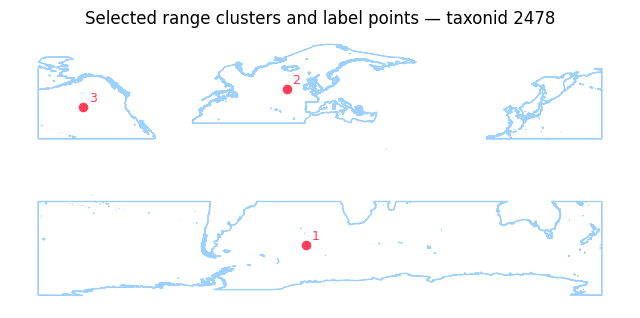

In [8]:
# Set EXPLORE_TAXONID to one taxonid from multi_centroid_summary, or leave None to inspect the first one.
EXPLORE_TAXONID = None
SHOW_EXPLORE_MAP = True

explore_centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence_label", "spatial_seasonal_label",
    "computed_range_area_km2", "computed_range_component_area_km2",
]
missing_centroid_cols = [col for col in explore_centroid_cols if col not in centroids.columns]
if missing_centroid_cols:
    raise RuntimeError(f"Run the spatial centroid cell before this exploration cell. Missing columns: {missing_centroid_cols}")

taxa_for_explore = df.drop(columns=[col for col in explore_centroid_cols if col != "taxonid"], errors="ignore").copy()
taxa_for_explore["taxonid"] = taxa_for_explore["taxonid"].astype(int)
taxa_for_explore = taxa_for_explore.drop_duplicates(subset="taxonid")
explore_df = taxa_for_explore.merge(centroids[explore_centroid_cols], on="taxonid", how="inner")

multi_centroid_summary = (
    explore_df.groupby(["taxonid", "scientific_name", "main_common_name", "category_iucn"], dropna=False)
    .agg(
        label_points=("centroid_rank", "count"),
        source=("centroid_source", first_non_empty),
        selected_presence=("spatial_presence_label", first_non_empty),
        selected_season=("spatial_seasonal_label", first_non_empty),
        components_available=("range_component_count", "max"),
        clusters_available=("range_cluster_count", "max"),
        cluster_buffer_km=("range_cluster_buffer_km", first_non_empty),
        total_range_area_km2=("computed_range_area_km2", "max"),
    )
    .reset_index()
    .query("label_points > 1")
    .sort_values(["label_points", "total_range_area_km2"], ascending=[False, False])
)

print(f"Taxa with several label points: {len(multi_centroid_summary):,}")
display(multi_centroid_summary.head(25))

if multi_centroid_summary.empty:
    print("No taxa with several label points in the current sample.")
else:
    selected_taxonid = int(EXPLORE_TAXONID or multi_centroid_summary.iloc[0].taxonid)
    print(f"Exploring taxonid: {selected_taxonid}")

    selected_points = (
        explore_df[explore_df["taxonid"].astype(int) == selected_taxonid]
        .sort_values("centroid_rank")
        [[
            "taxonid", "scientific_name", "main_common_name", "category_iucn",
            "centroid_rank", "centroid_count", "centroid_source", "lon", "lat",
            "computed_range_component_area_km2", "computed_range_area_km2",
            "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
            "spatial_presence_label", "spatial_seasonal_label",
        ]]
    )
    display(selected_points)

    selected_centroid_geoms = centroids[centroids["taxonid"].astype(int) == selected_taxonid].sort_values("centroid_rank")
    selected_range_geom = range_geometries[range_geometries["taxonid"].astype(int) == selected_taxonid]
    selected_clusters = gpd.GeoDataFrame(columns=["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label", "geometry"], geometry="geometry", crs="EPSG:4326")
    if not selected_range_geom.empty:
        selected_parts = polygon_parts(selected_range_geom.iloc[0].geometry)
        if selected_parts:
            selected_clusters = cluster_range_parts(selected_parts, RANGE_CLUSTER_BUFFER_KM).sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
            selected_clusters["cluster_rank"] = selected_clusters.index + 1
            selected_total_area = selected_clusters["cluster_area_km2"].sum()
            selected_clusters["range_cluster_area_share"] = 0.0
            if selected_total_area > 0:
                selected_clusters["range_cluster_area_share"] = selected_clusters["cluster_area_km2"] / selected_total_area
            selected_clusters["selected_for_label"] = (
                (selected_clusters["cluster_rank"] == 1)
                | (
                    (selected_clusters["cluster_rank"] <= MAX_RANGE_CENTROIDS_PER_SPECIES)
                    & (selected_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
                )
            )
            display(selected_clusters[["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label"]].head(30))
    selected_raw_polygons = polygon_gdf[polygon_gdf["taxonid"].astype(int) == selected_taxonid].copy()
    if not selected_raw_polygons.empty:
        selected_raw_polygons = selected_raw_polygons.copy()
        selected_raw_polygons["raw_polygon_area_km2"] = selected_raw_polygons.to_crs(6933).area / 1e6
        display(
            selected_raw_polygons
            .assign(
                spatial_presence_label=lambda d: d["spatial_presence"].map(presence_label),
                spatial_seasonal_label=lambda d: d["spatial_seasonal"].map(seasonal_label),
            )
            .sort_values("raw_polygon_area_km2", ascending=False)
            [["taxonid", "raw_polygon_area_km2", "spatial_presence_label", "spatial_seasonal_label", "source_path"]]
            .head(30)
        )

    if SHOW_EXPLORE_MAP:
        ax = selected_range_geom.boundary.plot(figsize=(8, 5), color="#4b6fff", linewidth=0.45)
        if not selected_clusters.empty:
            selected_clusters.boundary.plot(ax=ax, color="#9bd0ff", linewidth=1.0)
        selected_centroid_geoms.plot(ax=ax, color="#ff3d5a", markersize=35)
        for row in selected_centroid_geoms.itertuples(index=False):
            ax.annotate(str(row.centroid_rank), (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", color="#ff3d5a", fontsize=9)
        ax.set_title(f"Selected range clusters and label points — taxonid {selected_taxonid}")
        ax.set_axis_off()


---
## 3 · Wikidata SPARQL — IUCN ID → Wikipedia article title

Both modes query Wikidata from IUCN taxon IDs. In sample mode, the batch is simply much smaller.

In [9]:
print("Wikidata language priority:", ", ".join(WIKIPEDIA_LANGUAGE_PRIORITY))


Wikidata language priority: en, de, ja, fr, es, ru, it, zh, pt, pl, nl, uk, ca, sv, cs, fi, ko, tr, no, da, eo


In [10]:
wikidata_taxon_ids = df["taxonid"].drop_duplicates().tolist()
wikidata_map = query_wikidata_batch(wikidata_taxon_ids)

# Name-based fallback: taxa whose IUCN taxon ID isn't linked in Wikidata
# (e.g. Catopuma temminckii stored as Pardofelis temminckii, or missing P627)
unresolved_ids = [t for t in wikidata_taxon_ids if str(t) not in wikidata_map]
if unresolved_ids:
    name_fallback = ph.query_wikidata_by_names(unresolved_ids, df)
    wikidata_map.update(name_fallback)

ph.configure(wikidata_map=wikidata_map)
print(f"Wikipedia articles found: {len(wikidata_map):,} / {len(wikidata_taxon_ids):,} taxa")
print(f"Raw Wikidata P18 images found before map-image filtering: {sum(1 for item in wikidata_map.values() if item.get('wikidata_image_url')):,}")
pd.Series([item.get("wiki_language") for item in wikidata_map.values()]).value_counts().head(10)


Wikidata batches:   0%|          | 0/1 [00:00<?, ?it/s]

Wikidata name fallback: 14 unresolved taxa → 36 P225 candidates
  [1/12] Neomicroxus latebricola ...   Entity search failed for 'Neomicroxus latebricola': 429 Client Error: Too Many Requests for url: https://query.wikidata.org/sparql?query=%0ASELECT+%3Ftaxon+%3Farticle+%3Farticle_lang+%3Fwiki_project+%3Farticle_title+%3Fwikidata_image_url+WHERE+%7B%0A++VALUES+%3Ftaxon+%7B+wd%3AQ27954543+wd%3AQ305746+%7D%0A++OPTIONAL+%7B+%3Ftaxon+wdt%3AP18+%3Fwikidata_image_url+.+%7D%0A++%3Farticle+schema%3Aabout+%3Ftaxon+%3B%0A++++++++++++schema%3AinLanguage+%3Farticle_lang+%3B%0A++++++++++++schema%3AisPartOf+%3Fwiki_site+.%0A++FILTER%28CONTAINS%28STR%28%3Fwiki_site%29%2C+%22.wikipedia.org%2F%22%29%29%0A++BIND%28REPLACE%28STR%28%3Fwiki_site%29%2C+%22%5Ehttps%3F%3A%2F%2F%22%2C+%22%22%29+AS+%3Fwiki_project_slash%29%0A++BIND%28REPLACE%28%3Fwiki_project_slash%2C+%22%2F%24%22%2C+%22%22%29+AS+%3Fwiki_project%29%0A++BIND%28REPLACE%28STR%28%3Farticle%29%2C+CONCAT%28%22https%3A%2F%2F%22%2C+%3Fwiki_project%2C+%2

en     194
avk     14
sr       1
it       1
de       1
fr       1
Name: count, dtype: int64

### Parent species Wikidata fallback

Wikipedia coverage is often at species level even when IUCN assesses a threatened subspecies. To avoid dropping those subspecies just because Wikidata/Wikipedia has no infrarank article, the notebook uses a parent-species lookup only when needed.

The displayed taxon stays the infrarank taxon: IUCN status, name, assessment URL, and spatial point remain tied to the displayed row. Only the article/image/pageviews lookup can be inherited from the parent. Parent IDs are queried only if they are missing from the local Wikidata cache, and the parent is never added as a displayed animal.

Rows using a parent article or pageview signal are marked with `wiki_lookup_source = "parent_species"`. Rows using only a parent image are marked separately with `image_lookup_source = "parent_species"`.


In [11]:
# Attach wiki title and Wikidata P18 image.
# If an infrarank taxon has no Wikipedia article, use its parent species as the
# Wikidata/Wikipedia/pageviews/image lookup source while keeping the displayed
# IUCN taxon and conservation status unchanged.
df["wiki_lookup_taxonid"] = df["taxonid"].astype(int)
df["wiki_lookup_source"] = "self"
attach_wikidata_fields(df, wikidata_map)

parent_taxonid_numeric = pd.to_numeric(df.get("parent_taxonid"), errors="coerce")
missing_self_wiki = df["wiki_title"].isna() & parent_taxonid_numeric.notna()
parent_wiki_ids = sorted(parent_taxonid_numeric[missing_self_wiki].dropna().astype(int).unique())
parent_wiki_ids_to_query = [taxonid for taxonid in parent_wiki_ids if str(taxonid) not in wikidata_map]
if parent_wiki_ids_to_query:
    parent_wikidata_map = query_wikidata_batch(parent_wiki_ids_to_query)
    wikidata_map.update(parent_wikidata_map)

parent_has_wiki = parent_taxonid_numeric.map(lambda taxonid: bool((wikidata_map.get(str(int(taxonid))) or {}).get("wiki_title")) if pd.notna(taxonid) else False)
parent_wiki_fallback = missing_self_wiki & parent_has_wiki
if parent_wiki_fallback.any():
    df.loc[parent_wiki_fallback, "wiki_lookup_taxonid"] = parent_taxonid_numeric[parent_wiki_fallback].astype(int)
    df.loc[parent_wiki_fallback, "wiki_lookup_source"] = "parent_species"
    attach_wikidata_fields(df, wikidata_map)

missing_wiki_taxa = (
    df[df["wiki_title"].isna()]
    .drop_duplicates(subset="taxonid")
    [["taxonid", "parent_taxonid", "scientific_name", "main_common_name", "category_iucn"]]
    .sort_values("taxonid")
)
df_wiki = df.dropna(subset=["wiki_title"]).copy()
print(f"Rows with a Wikidata-resolved Wikipedia article: {len(df_wiki):,} label points from {df_wiki.taxonid.nunique():,} taxa")
print(f"Taxa using parent-species Wikipedia fallback: {df_wiki[df_wiki['wiki_lookup_source'] == 'parent_species'].taxonid.nunique():,}")
print(f"Taxa without a Wikidata-resolved Wikipedia article after parent fallback: {len(missing_wiki_taxa):,}")
display(missing_wiki_taxa.head(20))
df_wiki.head()


Wikidata batches:   0%|          | 0/1 [00:00<?, ?it/s]

Rows with a Wikidata-resolved Wikipedia article: 252 label points from 221 taxa
Taxa using parent-species Wikipedia fallback: 9
Taxa without a Wikidata-resolved Wikipedia article after parent fallback: 0


,taxonid,parent_taxonid,scientific_name,main_common_name,category_iucn


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url
0,18,22182349,2016-03-01T00:00:00.000+00:00,2016,https://www.iucnredlist.org/species/18/22182349,"Bernal, N. 2016. Abrocoma boliviensis. The IUC...",Abrocoma boliviensis,Bolivian Chinchilla Rat,CR,Decreasing,...,10 October 2025,IUCN SSC Small Mammal Specialist Group 2016. T...,18,self,Bolivian_chinchilla_rat,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Bolivian_chinchi...,https://www.wikidata.org/entity/Q1769964,None
1,137,220501878,2022-07-10T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/137/220501878,"Sheherazade, Tsang, S.M. & Matorang, Z. 2022. ...",Acerodon celebensis,Sulawesi Fruit Bat,VU,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,137,self,Sulawesi_flying_fox,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Sulawesi_flying_fox,https://www.wikidata.org/entity/Q301834,https://commons.wikimedia.org/wiki/Special:Fil...
2,138,115517951,2015-06-20T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/138/115517951,"Mildenstein, T. 2016. Acerodon humilis (errata...",Acerodon humilis,Talaud Fruit Bat,EN,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,138,self,Talaud_flying_fox,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Talaud_flying_fox,https://www.wikidata.org/entity/Q301625,None
3,139,21988328,2016-04-05T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/139/21988328,"Mildenstein, T. & Paguntalan, L. 2016. Acerodo...",Acerodon jubatus,Golden-capped Fruit Bat,EN,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,139,self,Giant_golden-crowned_flying_fox,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Giant_golden-cro...,https://www.wikidata.org/entity/Q775576,https://commons.wikimedia.org/wiki/Special:Fil...
4,140,21988055,2019-04-23T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/140/21988055,"Mildenstein, T., Widmann, P., Lacerna, I., Pag...",Acerodon leucotis,Palawan Fruit Bat,VU,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,140,self,Palawan_fruit_bat,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Palawan_fruit_bat,https://www.wikidata.org/entity/Q301741,None


In [60]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("nictitans")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url
172,41208,17984834,2016-10-24T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/41208/1798...,"Gonedelé Bi, S., Oates, J.F. & Koné, I. 2020. ...",Cercopithecus nictitans ssp. stampflii,Stampfli's Putty-nosed Monkey,EN,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,4224,parent_species,Greater_spot-nosed_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Greater_spot-nos...,https://www.wikidata.org/entity/Q1193818,https://commons.wikimedia.org/wiki/Special:Fil...
173,136922,92488572,2016-10-26T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/136922/924...,"Maisels, F. 2020. Cercopithecus nictitans ssp....",Cercopithecus nictitans ssp. nictitans,Eastern Putty-nosed Monkey,VU,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,136922,self,Medjitol_(Cercopithecus_nictitans_nictitans),avk,avk.wikipedia.org,https://avk.wikipedia.org/wiki/Medjitol_(Cerco...,https://www.wikidata.org/entity/Q20903141,None
174,92488656,222902568,2018-11-19T00:00:00.000+00:00,2021,https://www.iucnredlist.org/species/92488656/2...,"Ikemeh, R., Oates, J.F. & Imong, I. 2021. Cerc...",Cercopithecus nictitans ssp. insolitus,Nigerian Putty-nosed Monkey,EN,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,4224,parent_species,Greater_spot-nosed_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Greater_spot-nos...,https://www.wikidata.org/entity/Q1193818,https://commons.wikimedia.org/wiki/Special:Fil...
175,92488692,222903914,2017-07-27T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/92488692/2...,"Gadsby, E.L., Imong, I. & Ndeloh, D. 2020. Cer...",Cercopithecus nictitans ssp. ludio,Red-rumped Putty-nosed Monkey,VU,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,4224,parent_species,Greater_spot-nosed_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Greater_spot-nos...,https://www.wikidata.org/entity/Q1193818,https://commons.wikimedia.org/wiki/Special:Fil...
176,92489579,17984755,2016-10-24T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/92489579/1...,"Cronin, D.T. 2020. Cercopithecus nictitans ssp...",Cercopithecus nictitans ssp. martini,Bioko Putty-nosed Monkey,EN,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,92489579,self,Medjitol_(Cercopithecus_nictitans_martini),avk,avk.wikipedia.org,https://avk.wikipedia.org/wiki/Medjitol_(Cerco...,https://www.wikidata.org/entity/Q20903143,None


In [12]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("latebricola")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url
14,741,22382354,2016-07-11T01:00:00.000+01:00,2019,https://www.iucnredlist.org/species/741/22382354,"Alvarado Serrano, D. 2019. Neomicroxus latebri...",Neomicroxus latebricola,Ecuadorean Grass Mouse,EN,Decreasing,...,10 October 2025,IUCN SSC Small Mammal Specialist Group 2019. T...,741,self,Ecuadorian_grass_mouse,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Ecuadorian_grass...,https://www.wikidata.org/entity/Q305746,None


---
## 4 · Wikimedia Pageviews API — 12-month view count

Endpoint: `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/monthly/{start}/{end}`

We use the last 12 completed months and sum the monthly totals.

In [13]:
# Last 12 completed months. Wikimedia's monthly endpoint expects YYYYMMDD.
today = date.today()
current_month_start = date(today.year, today.month, 1)
start_month = date(current_month_start.year - 1, current_month_start.month, 1)
if current_month_start.month == 1:
    end_month = date(current_month_start.year - 1, 12, 1)
else:
    end_month = date(current_month_start.year, current_month_start.month - 1, 1)
START = start_month.strftime("%Y%m01")
END = end_month.strftime("%Y%m01")
PAGEVIEW_MONTHS = (end_month.year - start_month.year) * 12 + end_month.month - start_month.month + 1
ph.set_pageview_window(START, END)

print(f"Pageview window: {START} → {END} inclusive ({PAGEVIEW_MONTHS} monthly buckets)")

# Run once per unique article, then map back to each output label point.
article_keys = df_wiki[["wiki_project", "wiki_title"]].drop_duplicates()
pageview_map = {}
for row in tqdm(article_keys.itertuples(index=False), total=len(article_keys), desc="Pageviews"):
    _views = get_pageviews(row.wiki_project, row.wiki_title)
    pageview_map[(row.wiki_project, row.wiki_title)] = _views
    tqdm.write(f"  {_views:>7,}  {row.wiki_title}")
    time.sleep(SLEEP_WIKI)

df_wiki["popularity"] = df_wiki.apply(lambda row: pageview_map.get((row.wiki_project, row.wiki_title), 0), axis=1).astype(int)


# If a subspecies has its own article but no pageviews in the selected window,
# use the parent species article/pageviews when available. This keeps parent calls narrow.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
zero_pageviews_with_parent = df_wiki["popularity"].eq(0) & df_wiki_parent_taxonid.notna()
if zero_pageviews_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[zero_pageviews_with_parent])
    parent_pageviews = {}
    for parent_id in sorted(df_wiki_parent_taxonid[zero_pageviews_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        if not entry.get("wiki_title"):
            continue
        key = (entry.get("wiki_project"), entry.get("wiki_title"))
        if key not in pageview_map:
            pageview_map[key] = get_pageviews(*key)
            time.sleep(SLEEP_WIKI)
        parent_pageviews[parent_id] = pageview_map.get(key, 0)
    parent_popularity = df_wiki_parent_taxonid.map(lambda taxonid: parent_pageviews.get(int(taxonid), 0) if pd.notna(taxonid) else 0)
    parent_pageview_fallback = zero_pageviews_with_parent & (parent_popularity > 0)
    if parent_pageview_fallback.any():
        apply_wikidata_entry_to_mask(df_wiki, parent_pageview_fallback, df_wiki_parent_taxonid, "parent_species")
        df_wiki.loc[parent_pageview_fallback, "popularity"] = parent_popularity[parent_pageview_fallback].astype(int)
        print(f"Parent-species pageview fallback applied: {df_wiki.loc[parent_pageview_fallback, 'taxonid'].nunique():,} taxa")

# Diagnose zero-popularity taxa (redirect titles, 404s, or genuinely no traffic)
zero_pop = df_wiki[df_wiki["popularity"] == 0].drop_duplicates(subset="taxonid")
if not zero_pop.empty:
    print(f"Zero-popularity taxa: {len(zero_pop):,}")
    for _, _r in zero_pop[["scientific_name", "wiki_title", "wiki_language", "wiki_url"]].iterrows():
        print(f"  {_r['scientific_name']} | {_r['wiki_language']} | {_r['wiki_title']} | {_r['wiki_url']}")

# Prefer Wikidata P18 images. Query Wikipedia thumbnails once per unique article,
# then Commons once per unique taxon, and map results back to all duplicate label points.
wikidata_map_like = df_wiki["wikidata_image_url"].map(is_probable_range_map_title)
excluded_wikidata_image_taxa = df_wiki.loc[wikidata_map_like, "taxonid"].nunique()
if excluded_wikidata_image_taxa:
    for _, _r in df_wiki.loc[wikidata_map_like, ["scientific_name", "wikidata_image_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikidata_image_url']}")
df_wiki.loc[wikidata_map_like, "wikidata_image_url"] = None
print(f"Map-like Wikidata P18 images excluded before thumbnail fallback: {excluded_wikidata_image_taxa:,} taxa")

thumbnail_map = {}
missing_image_articles = df_wiki.loc[df_wiki["wikidata_image_url"].isna(), ["wiki_project", "wiki_title"]].drop_duplicates()
print(f"Wikipedia thumbnail fallback requests: {len(missing_image_articles):,} unique articles")
for row in tqdm(missing_image_articles.itertuples(index=False), total=len(missing_image_articles), desc="Wikipedia thumbnails"):
    thumbnail_map[(row.wiki_project, row.wiki_title)] = get_wikipedia_thumbnail(row.wiki_project, row.wiki_title)
    time.sleep(SLEEP_WIKI)

df_wiki["wikipedia_thumbnail_url"] = df_wiki.apply(lambda row: thumbnail_map.get((row.wiki_project, row.wiki_title)), axis=1)
wikipedia_map_like = df_wiki["wikipedia_thumbnail_url"].map(is_probable_range_map_title)
excluded_wikipedia_image_taxa = df_wiki.loc[wikipedia_map_like, "taxonid"].nunique()
if excluded_wikipedia_image_taxa:
    for _, _r in df_wiki.loc[wikipedia_map_like, ["scientific_name", "wikipedia_thumbnail_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikipedia_thumbnail_url']}")
df_wiki.loc[wikipedia_map_like, "wikipedia_thumbnail_url"] = None

commons_map = {}
missing_thumbnail_taxa = df_wiki.loc[
    df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna(),
    ["taxonid", "scientific_name", "main_common_name"]
].drop_duplicates(subset="taxonid")
for row in tqdm(missing_thumbnail_taxa.itertuples(index=False), total=len(missing_thumbnail_taxa), desc="Commons images"):
    commons_map[str(row.taxonid)] = search_commons_image(row.scientific_name, row.main_common_name)
    time.sleep(SLEEP_WIKI)

commons_fields = [
    "commons_image_url", "commons_image_page_url", "commons_image_title", "commons_image_author",
    "commons_image_license", "commons_image_license_url", "commons_image_credit",
    "commons_image_search_source", "commons_image_search_term",
]
for field in commons_fields:
    df_wiki[field] = df_wiki["taxonid"].astype(str).map(lambda taxonid: (commons_map.get(taxonid) or {}).get(field))

df_wiki["image_url"] = df_wiki["wikidata_image_url"].fillna(df_wiki["wikipedia_thumbnail_url"]).fillna(df_wiki["commons_image_url"])
df_wiki["image_source"] = None
df_wiki.loc[df_wiki["wikidata_image_url"].notna(), "image_source"] = "Wikidata P18"
df_wiki.loc[df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].notna(), "image_source"] = "Wikipedia thumbnail"
df_wiki.loc[df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["commons_image_url"].notna(), "image_source"] = "Wikimedia Commons search"
df_wiki["image_lookup_taxonid"] = pd.to_numeric(df_wiki["wiki_lookup_taxonid"], errors="coerce")
df_wiki["image_lookup_source"] = df_wiki["wiki_lookup_source"]

# If every direct image fallback failed for an infrarank taxon, try the parent species image
# without changing the displayed taxon identity. Only image-missing rows trigger this work.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
missing_image_with_parent = df_wiki["image_url"].isna() & df_wiki_parent_taxonid.notna()
if missing_image_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[missing_image_with_parent])
    parent_image_map = {}
    for parent_id in sorted(df_wiki_parent_taxonid[missing_image_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        parent_wikidata_image = entry.get("wikidata_image_url")
        if is_probable_range_map_title(parent_wikidata_image):
            parent_wikidata_image = None
        parent_thumbnail = None
        if not parent_wikidata_image and entry.get("wiki_project") and entry.get("wiki_title"):
            parent_thumbnail = get_wikipedia_thumbnail(entry.get("wiki_project"), entry.get("wiki_title"))
            time.sleep(SLEEP_WIKI)
            if is_probable_range_map_title(parent_thumbnail):
                parent_thumbnail = None
        parent_image_map[parent_id] = {
            "wikidata_image_url": parent_wikidata_image,
            "wikipedia_thumbnail_url": parent_thumbnail,
        }

    parent_image_url = df_wiki_parent_taxonid.map(
        lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url")
        or (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url")
    )
    parent_image_fallback = missing_image_with_parent & parent_image_url.notna()
    if parent_image_fallback.any():
        parent_wikidata_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url"))
        parent_thumbnail_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url"))
        df_wiki.loc[parent_image_fallback, "wikidata_image_url"] = parent_wikidata_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "wikipedia_thumbnail_url"] = parent_thumbnail_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_url"] = parent_image_url[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_lookup_taxonid"] = df_wiki_parent_taxonid[parent_image_fallback].astype(int)
        df_wiki.loc[parent_image_fallback, "image_lookup_source"] = "parent_species"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.notna(), "image_source"] = "Parent species Wikidata P18"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.isna() & parent_thumbnail_values.notna(), "image_source"] = "Parent species Wikipedia thumbnail"
        print(f"Parent-species image fallback applied: {df_wiki.loc[parent_image_fallback, 'taxonid'].nunique():,} taxa")

image_taxa = df_wiki.drop_duplicates(subset="taxonid")
print(f"Map-like Wikipedia thumbnail images excluded: {excluded_wikipedia_image_taxa:,} taxa")
print(f"Commons fallback images found: {image_taxa.commons_image_url.notna().sum():,} taxa")
print(f"Images found: {image_taxa.image_url.notna().sum():,} / {len(image_taxa):,} taxa ({df_wiki.image_url.notna().sum():,} label points)")
df_wiki.head()


Pageview window: 20250601 → 20260501 inclusive (12 monthly buckets)


Pageviews:   0%|          | 0/216 [00:00<?, ?it/s]

    2,553  Bolivian_chinchilla_rat
    5,381  Sulawesi_flying_fox
    2,233  Talaud_flying_fox
  305,220  Giant_golden-crowned_flying_fox
    3,738  Palawan_fruit_bat
    2,678  Sunda_flying_fox
   18,645  Northeast_African_cheetah
   83,189  Addax
    6,856  Mountain_paca
  1,242,416  Giant_panda
  1,000,503  Red_panda
      932  Ecuadorian_grass_mouse
    1,084  Abrothrix_sanborni
      791  Cochabamba_grass_mouse
      923  Silent_grass_mouse
    5,123  Hairy-eared_dwarf_lemur
   11,038  Yucatán_black_howler
    2,545  Maranhão_red-handed_howler
    1,449  Central_Kashmir_vole
    1,563  Royle's_mountain_vole
    2,044  Gunning's_golden_mole
    4,852  Juliana's_golden_mole
   30,039  Dibatag
    4,518  San_Joaquin_antelope_squirrel
   66,989  Barbary_sheep
    2,580  Smoky_bat
    2,933  Aquatic_rat
    1,830  Flower-faced_bat
    2,489  Van_Gelder's_bat
   38,715  African_clawless_otter
   13,133  Congo_clawless_otter
    4,516  Peruvian_night_monkey
    4,237  Gray-handed_night_m

Wikipedia thumbnails:   0%|          | 0/62 [00:00<?, ?it/s]

  Abrocoma boliviensis: https://upload.wikimedia.org/wikipedia/commons/thumb/7/7b/Abrocoma_boliviensis_map.svg/3840px-Abrocoma_boliviensis_map.svg.png
  Acerodon humilis: https://upload.wikimedia.org/wikipedia/commons/c/c7/Talaud_Flying_Fox_area.png
  Acerodon leucotis: https://upload.wikimedia.org/wikipedia/commons/8/83/Palawan_Fruit_Bat_area.png
  Alouatta ululata: https://upload.wikimedia.org/wikipedia/commons/4/4f/Maranhao_Red-handed_Howler_area.png
  Neamblysomus gunningi: https://upload.wikimedia.org/wikipedia/commons/0/04/Gunning%27s_Golden_Mole_area.png
  Aproteles bulmerae: https://upload.wikimedia.org/wikipedia/commons/8/8d/Distribution_of_Aproteles_bulmerae.png
  Archboldomys luzonensis: https://upload.wikimedia.org/wikipedia/commons/b/b0/Range_Archboldomys_luzonensis.png
  Balantiopteryx infusca: https://upload.wikimedia.org/wikipedia/commons/b/bc/Ecuadorian_Sac-Winged_Bat_area.png
  Bdeogale jacksoni: https://upload.wikimedia.org/wikipedia/commons/1/18/Jackson%27s_Mongoose

Commons images:   0%|          | 0/44 [00:00<?, ?it/s]

Map-like Wikipedia thumbnail images excluded: 28 taxa
Commons fallback images found: 11 taxa
Images found: 188 / 221 taxa (216 label points)


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source
0,18,22182349,2016-03-01T00:00:00.000+00:00,2016,https://www.iucnredlist.org/species/18/22182349,"Bernal, N. 2016. Abrocoma boliviensis. The IUC...",Abrocoma boliviensis,Bolivian Chinchilla Rat,CR,Decreasing,...,None,None,None,None,None,None,None,None,18,self
1,137,220501878,2022-07-10T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/137/220501878,"Sheherazade, Tsang, S.M. & Matorang, Z. 2022. ...",Acerodon celebensis,Sulawesi Fruit Bat,VU,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,137,self
2,138,115517951,2015-06-20T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/138/115517951,"Mildenstein, T. 2016. Acerodon humilis (errata...",Acerodon humilis,Talaud Fruit Bat,EN,Decreasing,...,edited by M.Minderhoud,Public domain,None,own work based on PD map,scientific_name,"""Acerodon humilis""",https://upload.wikimedia.org/wikipedia/commons...,Wikimedia Commons search,138,self
3,139,21988328,2016-04-05T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/139/21988328,"Mildenstein, T. & Paguntalan, L. 2016. Acerodo...",Acerodon jubatus,Golden-capped Fruit Bat,EN,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,139,self
4,140,21988055,2019-04-23T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/140/21988055,"Mildenstein, T., Widmann, P., Lacerna, I., Pag...",Acerodon leucotis,Palawan Fruit Bat,VU,Decreasing,...,None,None,None,None,None,None,None,None,140,self


In [14]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("nictitans")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source
172,41208,17984834,2016-10-24T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/41208/1798...,"Gonedelé Bi, S., Oates, J.F. & Koné, I. 2020. ...",Cercopithecus nictitans ssp. stampflii,Stampfli's Putty-nosed Monkey,EN,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,4224,parent_species
173,136922,92488572,2016-10-26T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/136922/924...,"Maisels, F. 2020. Cercopithecus nictitans ssp....",Cercopithecus nictitans ssp. nictitans,Eastern Putty-nosed Monkey,VU,Decreasing,...,None,None,None,None,None,None,https://upload.wikimedia.org/wikipedia/commons...,Wikipedia thumbnail,136922,self
174,92488656,222902568,2018-11-19T00:00:00.000+00:00,2021,https://www.iucnredlist.org/species/92488656/2...,"Ikemeh, R., Oates, J.F. & Imong, I. 2021. Cerc...",Cercopithecus nictitans ssp. insolitus,Nigerian Putty-nosed Monkey,EN,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,4224,parent_species
175,92488692,222903914,2017-07-27T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/92488692/2...,"Gadsby, E.L., Imong, I. & Ndeloh, D. 2020. Cer...",Cercopithecus nictitans ssp. ludio,Red-rumped Putty-nosed Monkey,VU,Decreasing,...,None,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,4224,parent_species
176,92489579,17984755,2016-10-24T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/92489579/1...,"Cronin, D.T. 2020. Cercopithecus nictitans ssp...",Cercopithecus nictitans ssp. martini,Bioko Putty-nosed Monkey,EN,Decreasing,...,None,None,None,None,None,None,https://upload.wikimedia.org/wikipedia/commons...,Wikipedia thumbnail,92489579,self


In [15]:
# sanity check
df_wiki[df_wiki.image_url.fillna('').str.contains("area")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_author,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source


In [16]:
df_wiki[['scientific_name','main_common_name','wiki_url', 'wikidata_url','image_url','popularity']].tail()

,scientific_name,main_common_name,wiki_url,wikidata_url,image_url,popularity
247,Crocidura glassi,Glass's Shrew,https://en.wikipedia.org/wiki/Glass%27s_shrew,https://www.wikidata.org/entity/Q303200,None,1444
248,Crocidura kivuana,Kivu Shrew,https://en.wikipedia.org/wiki/Kivu_shrew,https://www.wikidata.org/entity/Q306014,None,1376
249,Crocidura lanosa,Lemara Shrew,https://en.wikipedia.org/wiki/Kivu_long-haired...,https://www.wikidata.org/entity/Q306211,None,1228
250,Crocidura lucina,Lucina's Shrew,https://en.wikipedia.org/wiki/Lucina%27s_shrew,https://www.wikidata.org/entity/Q306048,None,1304
251,Crocidura manengubae,Manenguba Shrew,https://en.wikipedia.org/wiki/Manenguba_shrew,https://www.wikidata.org/entity/Q306438,None,1332


In [17]:
df_wiki.popularity[:-1]

0        2553
1        5381
2        2233
3      305220
4        3738
        ...  
246      1554
247      1444
248      1376
249      1228
250      1304
Name: popularity, Length: 251, dtype: int64

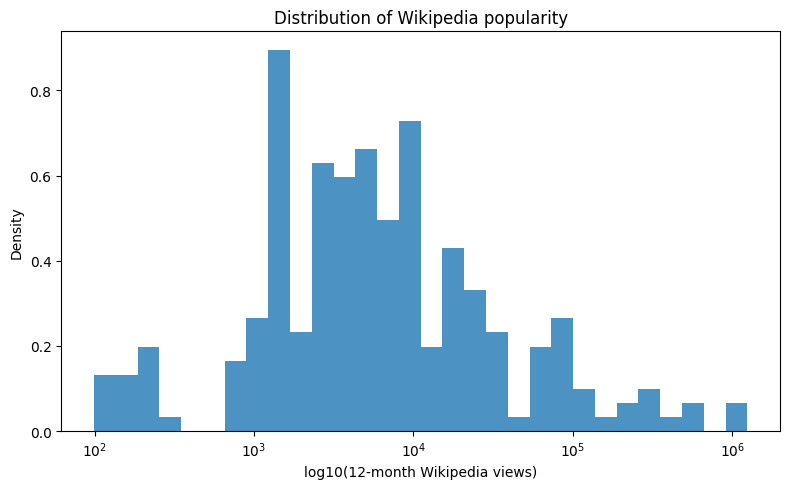

In [19]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

log_views = np.log10(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    log_views,
    bins=30,
    density=True,
    alpha=0.8,
)

ax.set_xlabel("log10(12-month Wikipedia views)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Wikipedia popularity")

# nicer tick labels
ticks = [2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f"$10^{t}$" for t in ticks])

plt.tight_layout()
plt.show()

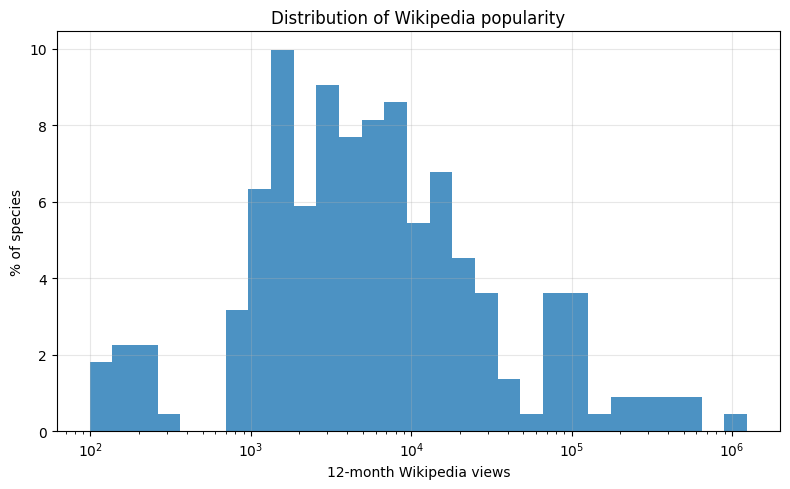

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

bins = np.logspace(
    np.log10(popularity.min()),
    np.log10(popularity.max()),
    30
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    popularity,
    bins=bins,
    weights=np.full(len(popularity), 100 / len(popularity)),
    alpha=0.8,
)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("% of species")
ax.set_title("Distribution of Wikipedia popularity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

count    2.210000e+02
mean     3.668033e+04
std      1.279476e+05
min      9.900000e+01
50%      5.123000e+03
75%      1.578000e+04
90%      7.276100e+04
95%      1.224530e+05
99%      6.144006e+05
max      1.242416e+06
Name: popularity, dtype: float64


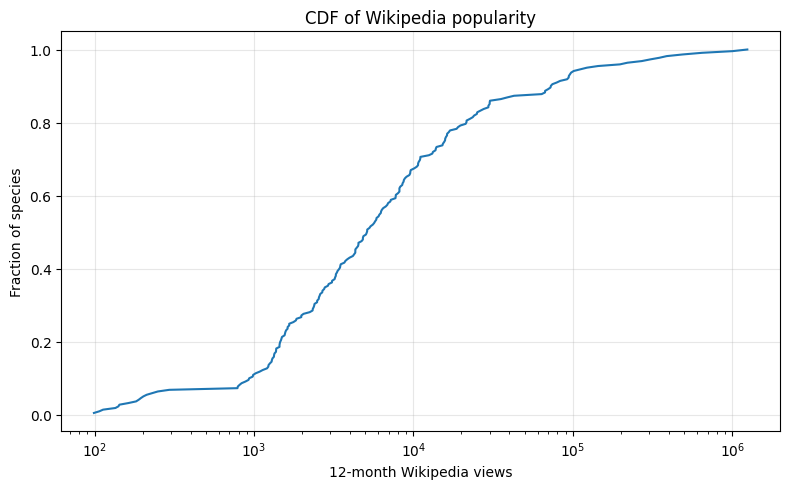

In [23]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
    .sort_values()
)

y = np.arange(1, len(popularity) + 1) / len(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(popularity, y)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("Fraction of species")
ax.set_title("CDF of Wikipedia popularity")

ax.grid(alpha=0.3)

print(popularity.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.tight_layout()
plt.show()

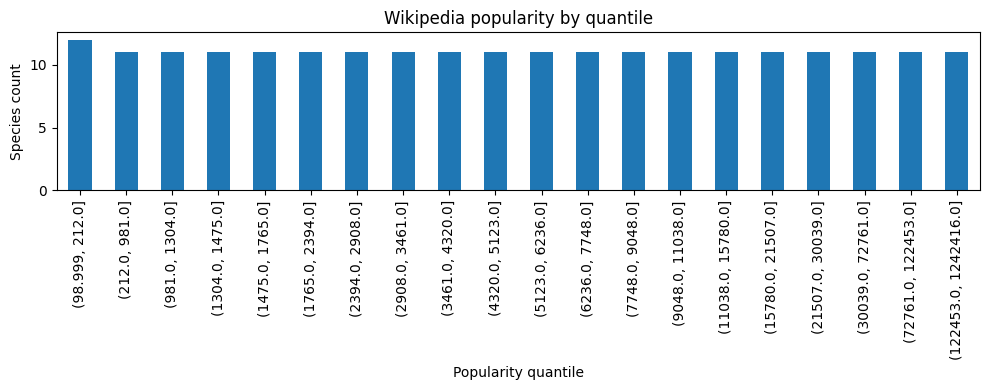

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

q = pd.qcut(popularity, q=20)

counts = q.value_counts(sort=False)

fig, ax = plt.subplots(figsize=(10, 4))

counts.plot.bar(ax=ax)

ax.set_ylabel("Species count")
ax.set_xlabel("Popularity quantile")
ax.set_title("Wikipedia popularity by quantile")

plt.tight_layout()
plt.show()

---
## 5 · Label selection & GeoJSON export

In [24]:
# Label: prefer main_common_name, fall back to scientific_name, then IUCN taxon ID.
common_label = df_wiki["main_common_name"].notna() & (df_wiki["main_common_name"] != "")
scientific_label = df_wiki["scientific_name"].notna() & (df_wiki["scientific_name"] != "")
df_wiki["label"] = "IUCN taxon " + df_wiki["taxonid"].astype(str)
df_wiki.loc[scientific_label, "label"] = df_wiki.loc[scientific_label, "scientific_name"]
df_wiki.loc[common_label, "label"] = df_wiki.loc[common_label, "main_common_name"].str.title()

# Drop species with 0 views (no Wikipedia presence → won't render usefully)
df_wiki = df_wiki[df_wiki.popularity > 0]

print(f"Final taxon count: {df_wiki.taxonid.nunique():,}")
print(f"Final points count: {len(df_wiki):,}")
df_wiki.head()

Final taxon count: 221
Final points count: 252


,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,commons_image_license,commons_image_license_url,commons_image_credit,commons_image_search_source,commons_image_search_term,image_url,image_source,image_lookup_taxonid,image_lookup_source,label
0,18,22182349,2016-03-01T00:00:00.000+00:00,2016,https://www.iucnredlist.org/species/18/22182349,"Bernal, N. 2016. Abrocoma boliviensis. The IUC...",Abrocoma boliviensis,Bolivian Chinchilla Rat,CR,Decreasing,...,None,None,None,None,None,None,None,18,self,Bolivian Chinchilla Rat
1,137,220501878,2022-07-10T01:00:00.000+01:00,2022,https://www.iucnredlist.org/species/137/220501878,"Sheherazade, Tsang, S.M. & Matorang, Z. 2022. ...",Acerodon celebensis,Sulawesi Fruit Bat,VU,Decreasing,...,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,137,self,Sulawesi Fruit Bat
2,138,115517951,2015-06-20T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/138/115517951,"Mildenstein, T. 2016. Acerodon humilis (errata...",Acerodon humilis,Talaud Fruit Bat,EN,Decreasing,...,Public domain,None,own work based on PD map,scientific_name,"""Acerodon humilis""",https://upload.wikimedia.org/wikipedia/commons...,Wikimedia Commons search,138,self,Talaud Fruit Bat
3,139,21988328,2016-04-05T01:00:00.000+01:00,2016,https://www.iucnredlist.org/species/139/21988328,"Mildenstein, T. & Paguntalan, L. 2016. Acerodo...",Acerodon jubatus,Golden-capped Fruit Bat,EN,Decreasing,...,None,None,None,None,None,https://commons.wikimedia.org/wiki/Special:Fil...,Wikidata P18,139,self,Golden-Capped Fruit Bat
4,140,21988055,2019-04-23T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/140/21988055,"Mildenstein, T., Widmann, P., Lacerna, I., Pag...",Acerodon leucotis,Palawan Fruit Bat,VU,Decreasing,...,None,None,None,None,None,None,None,140,self,Palawan Fruit Bat


In [25]:
# Build lightweight centroid GeoJSON used by the browser
features = []
required_geojson_cols = {"lon", "lat"}
missing_geojson_cols = required_geojson_cols - set(df_wiki.columns)
if missing_geojson_cols:
    raise RuntimeError(f"Missing centroid coordinate columns before GeoJSON export: {sorted(missing_geojson_cols)}. Rerun the spatial centroid merge cell before exporting.")
for _, row in df_wiki.iterrows():
    lon = clean_json_value(row["lon"])
    lat = clean_json_value(row["lat"])
    if lon is None or lat is None:
        continue
    props = feature_properties(row)
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(lon), 4), round(float(lat), 4)]
        },
        "properties": props
    })

geojson = {"type": "FeatureCollection", "features": features}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"Written: {OUTPUT_PATH} — {len(features):,} centroid features, {size_mb:.1f} MB")

# Build full spatial GeoJSON as a sidecar. This can be much heavier than the
# browser-facing point file, so keep it separate.
spatial_features = []
spatial_geometry_cols = [col for col in spatial_geometries.columns if col != "taxonid"]
spatial_conflict_cols = set(spatial_geometry_cols)
spatial_conflict_cols.update({f"{col}_x" for col in spatial_geometry_cols})
spatial_conflict_cols.update({f"{col}_y" for col in spatial_geometry_cols})
species_props_df = (
    df_wiki
    .drop(columns=[col for col in spatial_conflict_cols if col in df_wiki.columns], errors="ignore")
    .drop_duplicates(subset="taxonid")
    .copy()
)
spatial_df = species_props_df.merge(spatial_geometries, on="taxonid", how="inner", validate="one_to_many")
for _, row in spatial_df.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    props = feature_properties(row)
    props["spatial_source"] = row.spatial_source
    props["spatial_geometry_type"] = row.geometry.geom_type
    spatial_features.append({
        "type": "Feature",
        "geometry": mapping(row.geometry),
        "properties": props
    })

spatial_geojson = {"type": "FeatureCollection", "features": spatial_features}
with open(SPATIAL_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(spatial_geojson, f, ensure_ascii=False)

spatial_size_mb = os.path.getsize(SPATIAL_OUTPUT_PATH) / 1e6
print(f"Written: {SPATIAL_OUTPUT_PATH} — {len(spatial_features):,} spatial features, {spatial_size_mb:.1f} MB")


Written: animals.geojson — 252 centroid features, 0.7 MB
Written: animals-spatial.geojson — 221 spatial features, 184.0 MB


---
## Sanity check

In [ ]:
# Load back and inspect as a DataFrame
with open(OUTPUT_PATH, encoding="utf-8") as f:
    check = json.load(f)

records = []
for feat in check["features"]:
    props = dict(feat.get("properties") or {})
    geometry = feat.get("geometry") or {}
    coords = geometry.get("coordinates") or [None, None]
    props["geometry_type"] = geometry.get("type")
    props["lon"] = coords[0] if len(coords) > 0 else None
    props["lat"] = coords[1] if len(coords) > 1 else None
    records.append(props)

df_geojson = pd.DataFrame(records)
print(f"Loaded: {len(df_geojson):,} label points from {df_geojson['taxonid'].nunique():,} taxa")

preview_cols = [
    "taxonid", "label", "category_iucn", "taxon_class", "taxon_group",
    "centroid_rank", "centroid_count", "centroid_source", "popularity",
    "image_source", "image_lookup_source", "image_lookup_taxonid", "image_url", "wiki_url", "lat", "lon",
]
display(df_geojson[[col for col in preview_cols if col in df_geojson.columns]].head())

nilgiri_tahr = df_geojson[
    geojson_text_col(df_geojson, "label").str.casefold().eq("nilgiri tahr")
    | geojson_text_col(df_geojson, "wiki_title").str.casefold().eq("nilgiri_tahr")
]

print(f"Nilgiri Tahr rows: {len(nilgiri_tahr):,}")
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 160):
    display(nilgiri_tahr.T if len(nilgiri_tahr) == 1 else nilgiri_tahr)


In [8]:
# Query Wikidata for Nilgiri Tahr only
# This mirrors the section 3 lookup, but keeps the one-animal result easy to inspect.
if "nilgiri_tahr" not in globals() or nilgiri_tahr.empty:
    with open(OUTPUT_PATH, encoding="utf-8") as f:
        check = json.load(f)
    nilgiri_records = [
        feat.get("properties") or {}
        for feat in check["features"]
        if str((feat.get("properties") or {}).get("label", "")).casefold() == "nilgiri tahr"
        or str((feat.get("properties") or {}).get("wiki_title", "")).casefold() == "nilgiri_tahr"
    ]
    nilgiri_tahr = pd.DataFrame(nilgiri_records)

if nilgiri_tahr.empty:
    raise ValueError("Nilgiri Tahr was not found in the browser GeoJSON output.")

nilgiri_taxonid = str(nilgiri_tahr.iloc[0]["taxonid"])
print(f"Nilgiri Tahr IUCN taxon ID: {nilgiri_taxonid}")

nilgiri_pipeline_lookup = query_wikidata_batch([nilgiri_taxonid], batch_size=1)
nilgiri_pipeline_result = nilgiri_pipeline_lookup.get(nilgiri_taxonid, {})
display(pd.Series(nilgiri_pipeline_result, name="section_3_selected_result").to_frame())

nilgiri_sparql = f"""
SELECT ?taxon ?taxonLabel ?iucn_id ?rankLabel ?wikidata_image_url ?article ?article_lang ?wiki_project ?article_title WHERE {{
  VALUES ?iucn_id {{ \"{nilgiri_taxonid}\" }}
  ?taxon wdt:P627 ?iucn_id .
  OPTIONAL {{ ?taxon wdt:P105 ?rank . }}
  OPTIONAL {{ ?taxon wdt:P18 ?wikidata_image_url . }}
  OPTIONAL {{
    ?article schema:about ?taxon ;
             schema:inLanguage ?article_lang ;
             schema:isPartOf ?wiki_site .
    FILTER(CONTAINS(STR(?wiki_site), \".wikipedia.org/\"))
    BIND(REPLACE(STR(?wiki_site), \"^https?://\", \"\") AS ?wiki_project_slash)
    BIND(REPLACE(?wiki_project_slash, \"/$\", \"\") AS ?wiki_project)
    BIND(REPLACE(STR(?article), CONCAT(\"https://\", ?wiki_project, \"/wiki/\"), \"\") AS ?article_title)
  }}
  SERVICE wikibase:label {{ bd:serviceParam wikibase:language \"en,fr,de,es\". }}
}}
ORDER BY ?article_lang
"""

r = requests.get(
    WIKIDATA_ENDPOINT,
    params={"query": nilgiri_sparql, "format": "json"},
    headers={"User-Agent": USER_AGENT},
    timeout=60,
)
r.raise_for_status()

nilgiri_wikidata_rows = []
for binding in r.json()["results"]["bindings"]:
    row = {key: value.get("value") for key, value in binding.items()}
    if row.get("article_title"):
        row["article_title"] = urllib.parse.unquote(row["article_title"])
    if row.get("wikidata_image_url"):
        row["wikidata_image_url"] = row["wikidata_image_url"].replace("http://", "https://", 1)
    nilgiri_wikidata_rows.append(row)

df_nilgiri_wikidata = pd.DataFrame(nilgiri_wikidata_rows)
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 180):
    display(df_nilgiri_wikidata)


Nilgiri Tahr IUCN taxon ID: 9917


Wikidata batches:   0%|          | 0/1 [00:00<?, ?it/s]

,section_3_selected_result
wiki_title,Nilgiri_tahr
wiki_language,en
wiki_project,en.wikipedia.org
wiki_url,https://en.wikipedia.org/wiki/Nilgiri_tahr
wiki_rank,0
wikidata_image_url,https://commons.wikimedia.org/wiki/Special:Fil...


,taxon,article,article_lang,wiki_project,article_title,iucn_id,wikidata_image_url,taxonLabel,rankLabel
0,http://www.wikidata.org/entity/Q22111959,https://br.wikipedia.org/wiki/Tahr_Nilgiri,br,br.wikipedia.org,Tahr_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
1,http://www.wikidata.org/entity/Q22111959,https://ca.wikipedia.org/wiki/Tar_dels_Nilgiri,ca,ca.wikipedia.org,Tar_dels_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
2,http://www.wikidata.org/entity/Q22111959,https://da.wikipedia.org/wiki/Nilgiritahr,da,da.wikipedia.org,Nilgiritahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
3,http://www.wikidata.org/entity/Q22111959,https://de.wikipedia.org/wiki/Nilgiri-Tahr,de,de.wikipedia.org,Nilgiri-Tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
4,http://www.wikidata.org/entity/Q22111959,https://en.wikipedia.org/wiki/Nilgiri_tahr,en,en.wikipedia.org,Nilgiri_tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
5,http://www.wikidata.org/entity/Q22111959,https://es.wikipedia.org/wiki/Nilgiritragus_hylocrius,es,es.wikipedia.org,Nilgiritragus_hylocrius,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
6,http://www.wikidata.org/entity/Q22111959,https://fr.wikipedia.org/wiki/Tahr_des_Nilgiri,fr,fr.wikipedia.org,Tahr_des_Nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
7,http://www.wikidata.org/entity/Q22111959,https://hu.wikipedia.org/wiki/Nilgiri_tahr,hu,hu.wikipedia.org,Nilgiri_tahr,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
8,http://www.wikidata.org/entity/Q22111959,https://id.wikipedia.org/wiki/Tahr_nilgiri,id,id.wikipedia.org,Tahr_nilgiri,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
9,http://www.wikidata.org/entity/Q22111959,https://it.wikipedia.org/wiki/Nilgiritragus_hylocrius,it,it.wikipedia.org,Nilgiritragus_hylocrius,9917,https://commons.wikimedia.org/wiki/Special:FilePath/NilgiriTahr.JPG,Nilgiri tahr,species
